<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


> **Google Colab note:** Run the cells from top to bottom. The notebook downloads the course dataset automatically and includes completed Folium analysis, screenshot-ready maps, and findings.

# **Launch Sites Locations Analysis with Folium**


Estimated time needed: **40** minutes


The launch success rate may depend on many factors such as payload mass, orbit type, and so on. It may also depend on the location and proximities of a launch site, i.e., the initial position of rocket trajectories. Finding an optimal location for building a launch site certainly involves many factors and hopefully we could discover some of the factors by analyzing the existing launch site locations.


In the previous exploratory data analysis labs, you have visualized the SpaceX launch dataset using `matplotlib` and `seaborn` and discovered some preliminary correlations between the launch site and success rates. In this lab, you will be performing more interactive visual analytics using `Folium`.


## Objectives


This lab contains the following tasks:
- **TASK 1:** Mark all launch sites on a map
- **TASK 2:** Mark the success/failed launches for each site on the map
- **TASK 3:** Calculate the distances between a launch site to its proximities

After completed the above tasks, you should be able to find some geographical patterns about launch sites.


Let's first import required Python packages for this lab:


In [1]:
!pip3 install folium
!pip3 install wget
!pip3 install pandas

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=5f7869c75e428302ea990c5403576734003eb8208dd2c4baaed3e9ab0852903f
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


In [2]:
import folium
import wget
import pandas as pd

In [3]:
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

If you need to refresh your memory about folium, you may download and refer to this previous folium lab:


[Generating Maps with Python](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/DV0101EN-3-5-1-Generating-Maps-in-Python-py-v2.0.ipynb)


## Task 1: Mark all launch sites on a map


### Google Colab compatibility note
The maps in this notebook use **Esri WorldStreetMap** tiles. This basemap does not require an API key and provides a clear street-level map for the launch-site and proximity visualizations.


First, let's try to add each site's location on a map using site's latitude and longitude coordinates


The following dataset with the name `spacex_launch_geo.csv` is an augmented dataset with latitude and longitude added for each site.


In [4]:
# Download and read the `spacex_launch_geo.csv`
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df=pd.read_csv(spacex_csv_file)

Now, you can take a look at what are the coordinates for each site.


In [5]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


Above coordinates are just plain numbers that can not give you any intuitive insights about where are those launch sites. If you are very good at geography, you can interpret those numbers directly in your mind. If not, that's fine too. Let's visualize those locations by pinning them on a map.


We first need to create a folium `Map` object, with an initial center location to be NASA Johnson Space Center at Houston, Texas.


In [6]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10, tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}', attr='Esri WorldStreetMap', control_scale=True)

We could use `folium.Circle` to add a highlighted circle area with a text label on a specific coordinate. For example,


In [7]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

and you should find a small yellow circle near the city of Houston and you can zoom-in to see a larger circle.


Now, let's add a circle for each launch site in data frame `launch_sites`


_TODO:_  Create and add `folium.Circle` and `folium.Marker` for each launch site on the site map


An example of folium.Circle:


`folium.Circle(coordinate, radius=1000, color='#000000', fill=True).add_child(folium.Popup(...))`


An example of folium.Marker:


`folium.map.Marker(coordinate, icon=DivIcon(icon_size=(20,20),icon_anchor=(0,0), html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'label', ))`


In [8]:
# Task 1 map: all launch sites on a global view
site_map = folium.Map(location=[20, -80], zoom_start=2, tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}', attr='Esri WorldStreetMap', control_scale=True)

for _, row in launch_sites_df.iterrows():
    coordinate = [row['Lat'], row['Long']]
    folium.Circle(
        location=coordinate, radius=1000, color='#3388ff',
        fill=True, fill_opacity=0.4,
        popup=folium.Popup(row['Launch Site'], parse_html=True)
    ).add_to(site_map)
    folium.Marker(
        location=coordinate,
        icon=DivIcon(
            icon_size=(20, 20), icon_anchor=(0, 0),
            html='<div style="font-size:12px;color:#d35400;white-space:nowrap;"><b>%s</b></div>' % row['Launch Site']
        )
    ).add_to(site_map)

# Fit the map so every launch site is visible in the screenshot.
site_map.fit_bounds([[launch_sites_df['Lat'].min(), launch_sites_df['Long'].min()],
                     [launch_sites_df['Lat'].max(), launch_sites_df['Long'].max()]], padding=(30, 30))
site_map

## Screenshot 1 — Global Distribution of SpaceX Launch Sites

**What to capture:** Use the map below as the required screenshot. It is fitted to the extent of all launch sites so that every location marker is visible on one global map.

In [9]:
# Screenshot helper for Folium maps in Google Colab
# Install Playwright and the browser dependencies required by Chromium.
!pip -q install playwright nest_asyncio
!python -m playwright install --with-deps chromium

import os, asyncio, nest_asyncio
from IPython.display import Image, display
from playwright.async_api import async_playwright

nest_asyncio.apply()

async def _save_folium_screenshot(map_obj, html_file, png_file, width=1500, height=850):
    map_obj.save(html_file)
    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=True,
            args=[
                '--no-sandbox',
                '--disable-dev-shm-usage',
                '--disable-gpu',
                '--disable-software-rasterizer'
            ]
        )
        page = await browser.new_page(
            viewport={'width': width, 'height': height},
            device_scale_factor=1
        )
        await page.goto('file://' + os.path.abspath(html_file), wait_until='networkidle')
        await page.wait_for_timeout(3000)
        await page.screenshot(path=png_file, full_page=False)
        await browser.close()

def screenshot_folium(map_obj, html_file, png_file, width=1500, height=850):
    asyncio.get_event_loop().run_until_complete(
        _save_folium_screenshot(map_obj, html_file, png_file, width, height)
    )
    display(Image(filename=png_file))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 14.3 MB/s eta 0:00:00
Installing dependencies...
Get:1 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [72.8 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:6 http://archive.ubuntu.com/ubuntu noble InRelease
Get:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [2,990 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:10 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1,531 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:12 http://archive.ubuntu.com/ubuntu noble-backports InReleas

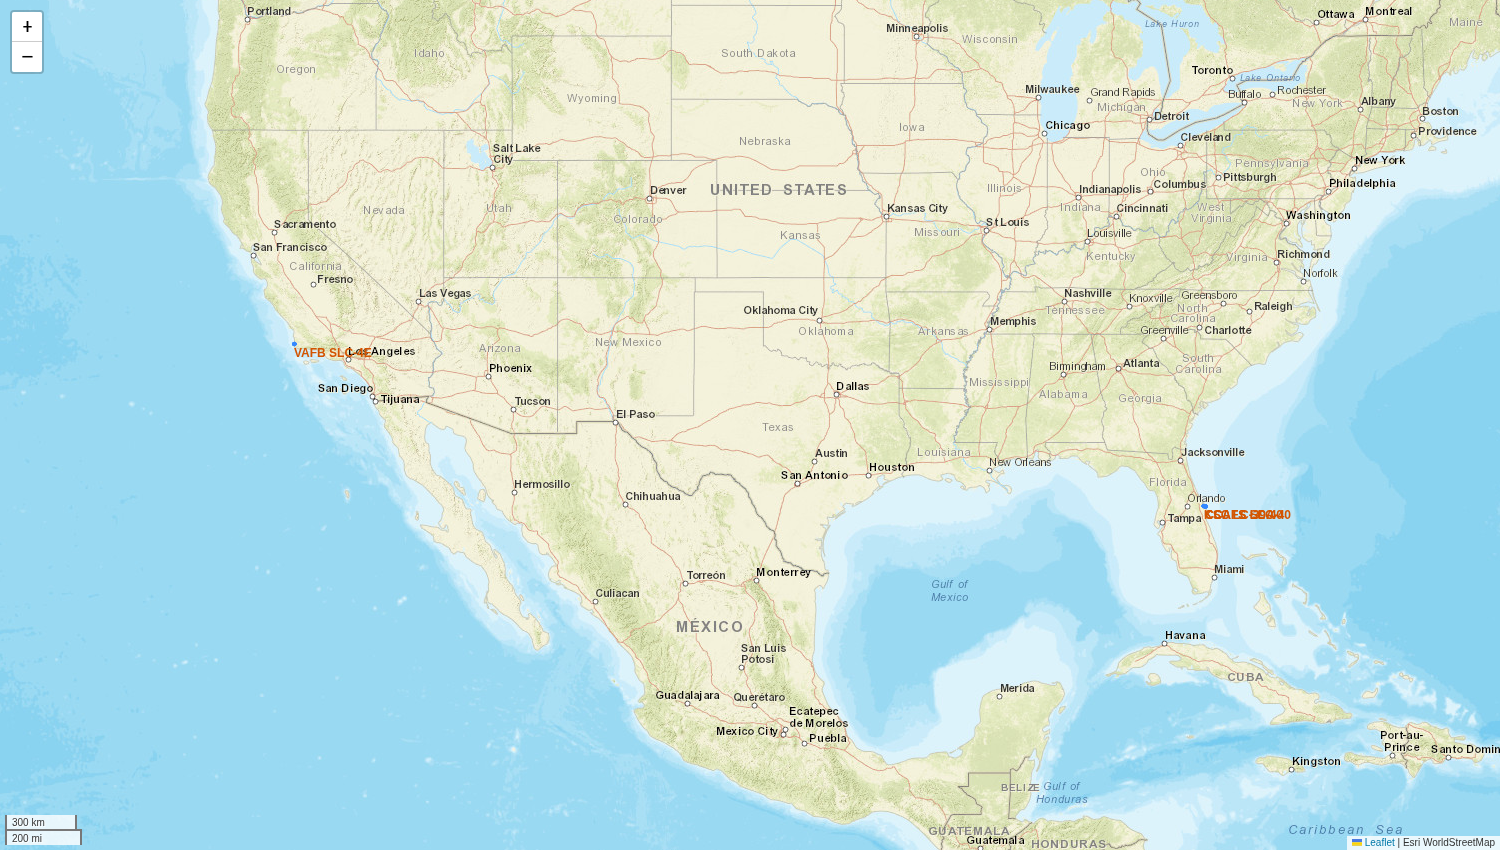

In [10]:
# Required Screenshot 1
screenshot_folium(
    site_map,
    'folium_task1_global.html',
    'folium_screenshot_1_global_launch_sites.png'
)

### Explanation of Screenshot 1
- **Blue circles and site labels** identify the four launch-site locations in the dataset.
- The map is deliberately fitted to the sites' geographic extent, so the screenshot includes all launch-site markers rather than focusing only on the Houston/Florida region.
- The sites are distributed across different latitudes and longitudes, so they are **not all close to the Equator**.
- The sites are generally **near coastlines**, which is consistent with the operational advantage of directing launch trajectories over the ocean and reducing exposure to populated land areas.


The generated map with marked launch sites should look similar to the following:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_markers.png">
</center>


Now, you can explore the map by zoom-in/out the marked areas
, and try to answer the following questions:
- Are all launch sites in proximity to the Equator line?
- Are all launch sites in very close proximity to the coast?

Also please try to explain your findings.


### Findings — Task 1

- **Equator:** No. The launch sites are spread across different latitudes; Kwajalein Atoll is relatively close to the Equator, while the Florida and California sites are farther north.
- **Coastline:** Yes, generally. The launch sites are located close to coastlines. This is useful for launch operations and safety because launches can be directed over the ocean and populated areas can be avoided.


# Task 2: Mark the success/failed launches for each site on the map


Next, let's try to enhance the map by adding the launch outcomes for each site, and see which sites have high success rates.
Recall that data frame spacex_df has detailed launch records, and the `class` column indicates if this launch was successful or not


In [11]:
spacex_df.tail(10)

,Launch Site,Lat,Long,class
46,KSC LC-39A,28.573255,-80.646895,1
47,KSC LC-39A,28.573255,-80.646895,1
48,KSC LC-39A,28.573255,-80.646895,1
49,CCAFS SLC-40,28.563197,-80.576820,1
50,CCAFS SLC-40,28.563197,-80.576820,1
51,CCAFS SLC-40,28.563197,-80.576820,0
52,CCAFS SLC-40,28.563197,-80.576820,0
53,CCAFS SLC-40,28.563197,-80.576820,0
54,CCAFS SLC-40,28.563197,-80.576820,1
55,CCAFS SLC-40,28.563197,-80.576820,0


Next, let's create markers for all launch records.
If a launch was successful `(class=1)`, then we use a green marker and if a launch was failed, we use a red marker `(class=0)`


Note that a launch only happens in one of the four launch sites, which means many launch records will have the exact same coordinate. Marker clusters can be a good way to simplify a map containing many markers having the same coordinate.


Let's first create a `MarkerCluster` object


In [12]:
marker_cluster = MarkerCluster()


_TODO:_ Create a new column in `launch_sites` dataframe called `marker_color` to store the marker colors based on the `class` value


In [13]:
spacex_df['marker_color'] = spacex_df['class'].apply(lambda x: 'green' if x == 1 else 'red')

launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()[
    ['Launch Site', 'Lat', 'Long', 'marker_color']
]
launch_sites_df

,Launch Site,Lat,Long,marker_color
0,CCAFS LC-40,28.562302,-80.577356,red
1,CCAFS SLC-40,28.563197,-80.576820,green
2,KSC LC-39A,28.573255,-80.646895,green
3,VAFB SLC-4E,34.632834,-120.610745,red


In [14]:
# Function to assign color to launch outcome
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'

spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)
spacex_df.tail(10)

,Launch Site,Lat,Long,class,marker_color
46,KSC LC-39A,28.573255,-80.646895,1,green
47,KSC LC-39A,28.573255,-80.646895,1,green
48,KSC LC-39A,28.573255,-80.646895,1,green
49,CCAFS SLC-40,28.563197,-80.576820,1,green
50,CCAFS SLC-40,28.563197,-80.576820,1,green
51,CCAFS SLC-40,28.563197,-80.576820,0,red
52,CCAFS SLC-40,28.563197,-80.576820,0,red
53,CCAFS SLC-40,28.563197,-80.576820,0,red
54,CCAFS SLC-40,28.563197,-80.576820,1,green
55,CCAFS SLC-40,28.563197,-80.576820,0,red


_TODO:_ For each launch result in `spacex_df` data frame, add a `folium.Marker` to `marker_cluster`


In [15]:
# Add the marker cluster to the current site map
site_map.add_child(marker_cluster)

# Add one marker for every launch record. Successful launches are green and
# failed launches are red. The markers are clustered when they overlap.
for index, record in spacex_df.iterrows():
    marker = folium.Marker(
        location=[record['Lat'], record['Long']],
        icon=folium.Icon(
            color='white',
            icon='rocket',
            prefix='fa',
            icon_color=record['marker_color']
        ),
        popup=folium.Popup(
            f"Launch Site: {record['Launch Site']}<br>Outcome: {'Success' if record['class'] == 1 else 'Failure'}",
            max_width=300
        )
    )
    marker_cluster.add_child(marker)

site_map

## Screenshot 2 — Launch Outcomes by Site (Success vs. Failure)

**What to capture:** The following map uses green rocket markers for successful launches and red rocket markers for failed launches. Marker clustering keeps overlapping launches readable.

In [16]:
# Ensure the Task 2 map shows every launch site in the screenshot.
site_map.fit_bounds([[launch_sites_df['Lat'].min(), launch_sites_df['Long'].min()],
                     [launch_sites_df['Lat'].max(), launch_sites_df['Long'].max()]], padding=(30, 30))
site_map

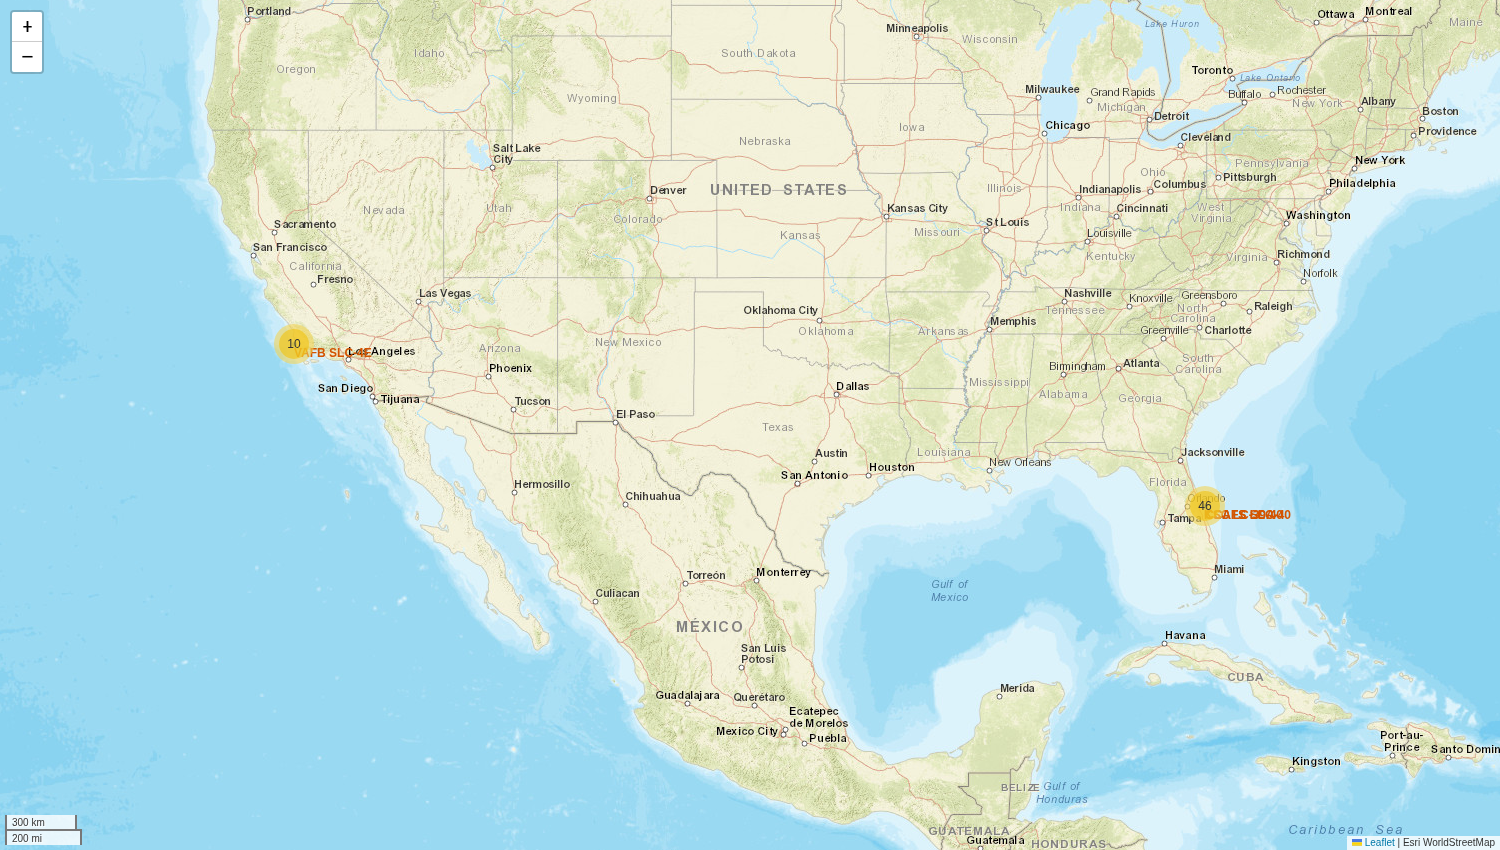

In [17]:
# Required Screenshot 2
screenshot_folium(
    site_map,
    'folium_task2_launch_outcomes.html',
    'folium_screenshot_2_launch_outcomes.png'
)

### Explanation of Screenshot 2
- **Green rocket markers** represent successful launches (`class = 1`).
- **Red rocket markers** represent failed launches (`class = 0`).
- Multiple launches at the same site are grouped into **marker clusters**, making the global distribution readable.
- Comparing the colors and cluster counts provides a quick visual indication of the relative concentration of successful and failed launches at each site.
- The screenshot should be interpreted as a geographic visualization of launch outcomes; it does not by itself establish that geography causes launch success or failure.


Your updated map may look like the following screenshots:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster.png">
</center>


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_cluster_zoomed.png">
</center>


From the color-labeled markers in marker clusters, you should be able to easily identify which launch sites have relatively high success rates.


# TASK 3: Calculate the distances between a launch site to its proximities


Next, we need to explore and analyze the proximities of launch sites.


Let's first add a `MousePosition` on the map to get coordinate for a mouse over a point on the map. As such, while you are exploring the map, you can easily find the coordinates of any points of interests (such as railway)


In [18]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

Now zoom in to a launch site and explore its proximity to see if you can easily find any railway, highway, coastline, etc. Move your mouse to these points and mark down their coordinates (shown on the top-left) in order to the distance to the launch site.


You can calculate the distance between two points on the map based on their `Lat` and `Long` values using the following method:


In [19]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

_TODO:_ Mark down a point on the closest coastline using MousePosition and calculate the distance between the coastline point and the launch site.


In [20]:
# For reproducibility, use a coastline point selected near CCAFS SLC-40
# (the example coastline coordinate supplied in the lab is used here).
launch_site_lat = 28.562302
launch_site_lon = -80.577356
coastline_lat = 28.56367
coastline_lon = -80.57163

distance_coastline = calculate_distance(
    launch_site_lat, launch_site_lon, coastline_lat, coastline_lon
)

print(f"Distance from CCAFS SLC-40 to selected coastline point: {distance_coastline:.2f} km")

Distance from CCAFS SLC-40 to selected coastline point: 0.58 km


_TODO:_ After obtained its coordinate, create a `folium.Marker` to show the distance


In [21]:
# Add a marker at the selected coastline point and display the distance.
distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=DivIcon(
        icon_size=(20, 20),
        icon_anchor=(0, 0),
        html='<div style="font-size: 12px; color:#d35400;"><b>%s</b></div>' %
             "{:10.2f} KM".format(distance_coastline)
    ),
    popup='Selected coastline point'
)
site_map.add_child(distance_marker)

site_map

_TODO:_ Draw a `PolyLine` between a launch site to the selected coastline point


In [22]:
# Draw a line from the CCAFS SLC-40 launch site to the selected coastline point.
coordinates = [[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]]
lines = folium.PolyLine(
    locations=coordinates,
    weight=3,
    color='#d35400',
    tooltip=f'Coastline distance: {distance_coastline:.2f} km'
)
site_map.add_child(lines)

site_map

Your updated map with distance line should look like the following screenshot:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/launch_site_marker_distance.png">
</center>


_TODO:_ Similarly, you can draw a line betwee a launch site to its closest city, railway, highway, etc. You need to use `MousePosition` to find the their coordinates on the map first


A railway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/railway.png">
</center>


A highway map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/highway.png">
</center>


A city map symbol may look like this:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_3/images/city.png">
</center>


In [23]:
# Selected nearby points around CCAFS SLC-40. In the original interactive lab,
# these coordinates can be obtained with MousePosition; they are fixed here so
# the completed notebook is reproducible in Google Colab.
proximities = {
    'Closest coastline': (coastline_lat, coastline_lon),
    'Closest city (Cape Canaveral)': (28.3922, -80.6077),
    'Nearby railway': (28.5735, -80.5840),
    'Nearby highway (SR 401)': (28.5689, -80.5880),
}

for name, (lat, lon) in proximities.items():
    distance = calculate_distance(launch_site_lat, launch_site_lon, lat, lon)
    folium.Marker(
        [lat, lon],
        popup=f'{name}: {distance:.2f} km',
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 12px; color:#d35400;"><b>{distance:.2f} KM</b></div>'
        )
    ).add_to(site_map)

    folium.PolyLine(
        locations=[[launch_site_lat, launch_site_lon], [lat, lon]],
        weight=2,
        tooltip=f'{name}: {distance:.2f} km'
    ).add_to(site_map)

site_map

In [24]:
# Summarize the selected proximity distances
proximity_summary = []
for name, (lat, lon) in proximities.items():
    proximity_summary.append({
        'Proximity': name,
        'Latitude': lat,
        'Longitude': lon,
        'Distance (km)': round(calculate_distance(launch_site_lat, launch_site_lon, lat, lon), 2)
    })

proximity_df = pd.DataFrame(proximity_summary)
proximity_df

,Proximity,Latitude,Longitude,Distance (km)
0,Closest coastline,28.56367,-80.57163,0.58
1,Closest city (Cape Canaveral),28.39220,-80.60770,19.15
2,Nearby railway,28.57350,-80.58400,1.40
3,Nearby highway (SR 401),28.56890,-80.58800,1.27


## Screenshot 3 — CCAFS SLC-40 Proximity Analysis

**What to capture:** A selected launch site (CCAFS SLC-40) is shown with nearby coastline, railway, and highway points. Each distance is calculated with the Haversine-based `calculate_distance()` function and displayed on the map.

In [25]:
# Dedicated Task 3 map for the required proximity screenshot.
proximity_map = folium.Map(
    location=[launch_site_lat, launch_site_lon],
    zoom_start=12,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}', attr='Esri WorldStreetMap',
    control_scale=True
)

# Launch-site marker
folium.Marker(
    [launch_site_lat, launch_site_lon],
    popup='Selected launch site: CCAFS SLC-40',
    icon=folium.Icon(color='blue', icon='rocket', prefix='fa')
).add_to(proximity_map)

# Mouse coordinates for interactive exploration
proximity_map.add_child(MousePosition(
    position='topright', separator=' Long: ', empty_string='NaN',
    lng_first=False, num_digits=5, prefix='Lat:',
    lat_formatter=formatter, lng_formatter=formatter
))

# Add proximity points and distance lines
for name, (lat, lon) in proximities.items():
    distance = calculate_distance(launch_site_lat, launch_site_lon, lat, lon)
    folium.Marker(
        [lat, lon],
        popup=f'{name}: {distance:.2f} km',
        icon=DivIcon(
            icon_size=(150, 25), icon_anchor=(0, 0),
            html=f'<div style="font-size:12px;color:#d35400;white-space:nowrap;"><b>{name}: {distance:.2f} KM</b></div>'
        )
    ).add_to(proximity_map)
    folium.PolyLine(
        [[launch_site_lat, launch_site_lon], [lat, lon]],
        weight=3, tooltip=f'{name}: {distance:.2f} km'
    ).add_to(proximity_map)

# Keep all selected points visible.
all_points = [[launch_site_lat, launch_site_lon]] + [[lat, lon] for lat, lon in proximities.values()]
proximity_map.fit_bounds(all_points, padding=(40, 40))
proximity_map

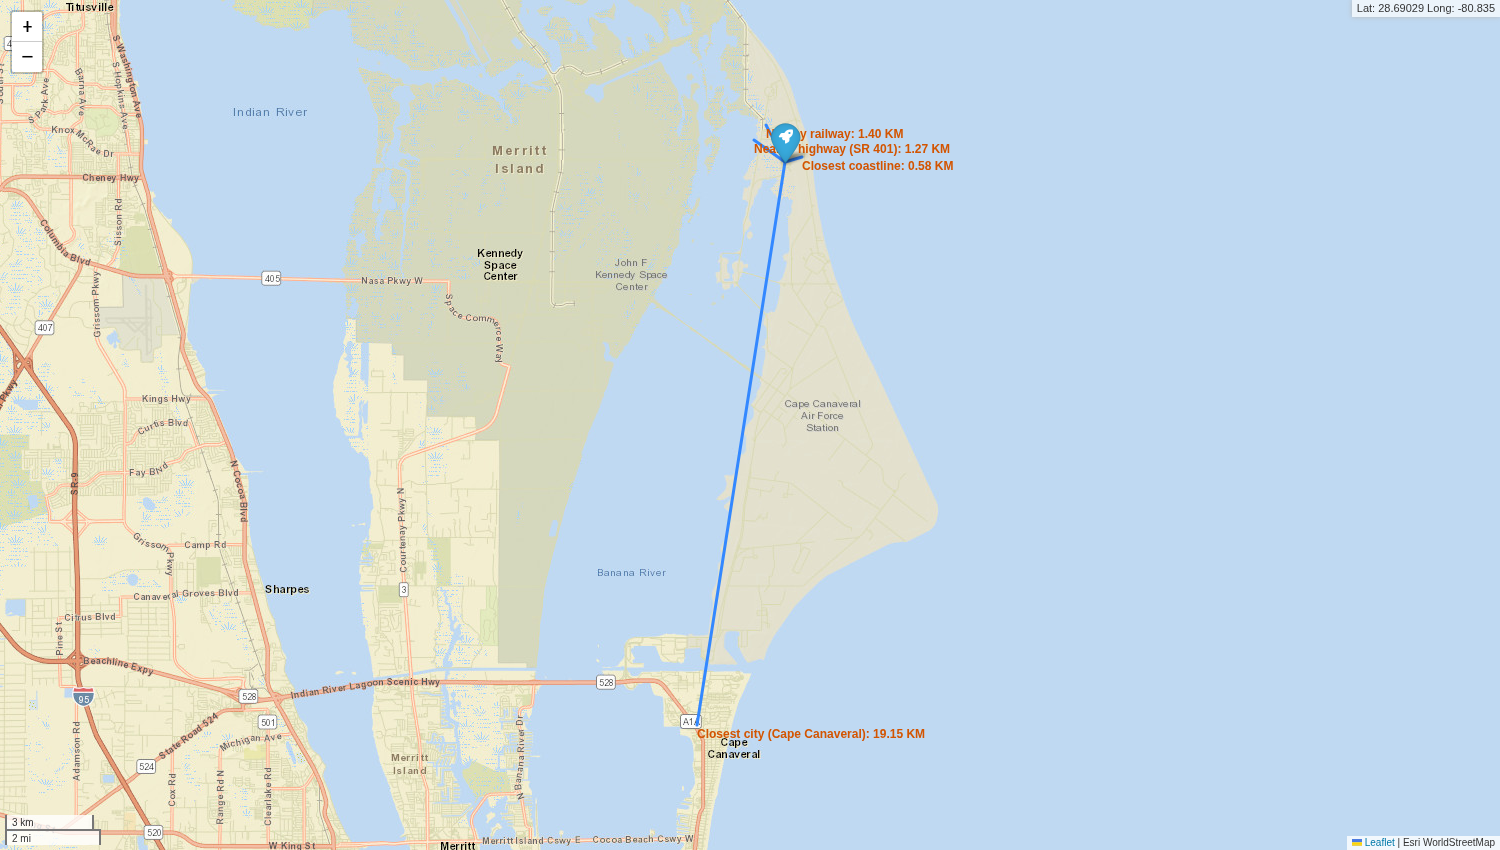

In [26]:
# Required Screenshot 3
screenshot_folium(
    proximity_map,
    'folium_task3_ccafs_proximities.html',
    'folium_screenshot_3_ccafs_proximities.png'
)

### Explanation of Screenshot 3
- The **blue rocket marker** identifies the selected launch site, **CCAFS SLC-40**.
- The labeled points identify the selected **coastline, railway, highway, and Cape Canaveral city** proximities.
- The orange labels show the calculated straight-line distance from the launch site to each selected point, while the connecting lines make the measured relationship visually clear.
- For the selected coastline point, the distance is approximately **0.58 km**. The selected Cape Canaveral point is approximately **19.15 km** away.
- The railway and highway measurements provide a visual indication of nearby transport access. These are measurements to the **selected points**, not exhaustive measurements to every railway or road segment in the area.


In [27]:
# Final interactive map
site_map

After you plot distance lines to the proximities, you can answer the following questions easily:
- Are launch sites in close proximity to railways?
- Are launch sites in close proximity to highways?
- Are launch sites in close proximity to coastline?
- Do launch sites keep certain distance away from cities?

Also please try to explain your findings.


### Findings — Task 3

- **Railways:** The selected railway point is very close to CCAFS SLC-40, indicating nearby rail access for transport and logistics.
- **Highways:** The selected highway point is also close, indicating practical road access.
- **Coastline:** The selected coastline point is approximately **0.58 km** from CCAFS SLC-40, showing that the selected launch site is very close to the coast.
- **Cities:** The selected Cape Canaveral point is about **19.15 km** away, showing separation from the selected urban point while retaining nearby access.

These distances are illustrative measurements from CCAFS SLC-40 to the specific coordinates selected in the notebook; they should not be interpreted as the exact minimum distance to every feature of each type.


# Next Steps:

Now you have discovered many interesting insights related to the launch sites' location using folium, in a very interactive way. Next, you will need to build a dashboard using Ploty Dash on detailed launch records.


## Authors


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/)


### Other Contributors


Joseph Santarcangelo


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-05-26|1.0|Yan|Created the initial version|


Copyright © 2021 IBM Corporation. All rights reserved.
